In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
pd.set_option('display.max_columns', None)

In [4]:
df = pd.read_csv('gurgaon_properties_outlier_treated.csv')

In [4]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
0,house,independent,sector 11,4.00,19753.0,2025.0,Built Up area: 225 (188.13 sq.m.)Carpet area: ...,5,4,1,2.0,North-East,Undefined,NaN,225.0,180.0,0,0,0,0,0,1,0,405.000000
1,flat,indiabulls enigma,sector 110,3.30,9851.0,3350.0,Super Built up area 3350(311.23 sq.m.),4,5,3,7.0,East,Relatively New,3350.0,NaN,NaN,0,1,0,0,0,1,101,837.500000
2,flat,puri emerald bay,sector 104,2.30,9388.0,2450.0,Super Built up area 2450(227.61 sq.m.),3,4,3+,10.0,North-East,Moderately Old,2450.0,NaN,NaN,0,1,0,0,0,1,101,816.666667
3,house,nirvana cedar crest,sector 50,3.99,8867.0,4500.0,Plot area 4500(418.06 sq.m.),4,5,3+,4.0,North-East,New Property,NaN,4500.0,NaN,0,1,0,1,0,0,112,1125.000000
4,flat,bptp terra,sector 37,1.45,8007.0,1811.0,Super Built up area 1811(168.25 sq.m.)Built Up...,3,3,3,8.0,South-East,Relatively New,1811.0,1711.0,1611.0,0,0,0,0,0,1,149,603.666667


In [5]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 18
facing                 1038
agePossession             0
super_built_up_area    1741
built_up_area          1991
carpet_area            1755
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

### built_up_area

<Axes: xlabel='built_up_area', ylabel='super_built_up_area'>

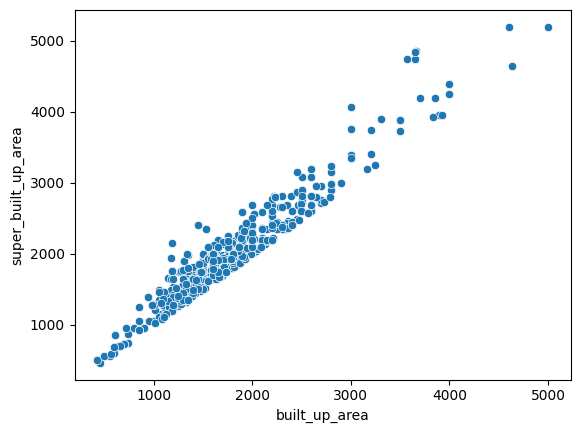

In [7]:
sns.scatterplot(x=df['built_up_area'],y=df['super_built_up_area'])

<Axes: xlabel='built_up_area', ylabel='carpet_area'>

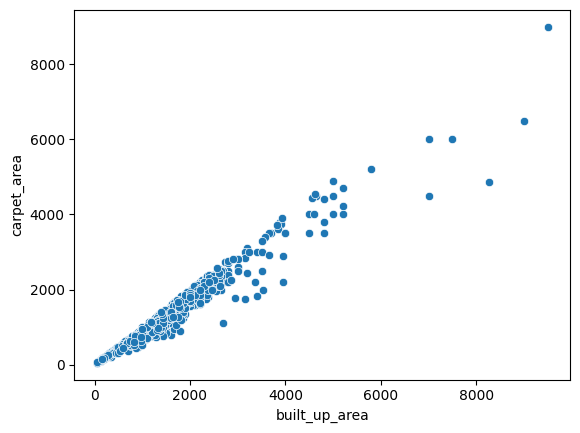

In [8]:
sns.scatterplot(x=df['built_up_area'],y=df['carpet_area'])

In [10]:
#all three are absent
((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull())).sum()

np.int64(0)

In [11]:
all_present_df = df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))]

In [12]:
all_present_df.shape

(532, 24)

In [13]:
super_to_built_up_ratio = (all_present_df['super_built_up_area']/all_present_df['built_up_area']).median()

In [14]:
carpet_to_built_up_ratio = (all_present_df['carpet_area']/all_present_df['built_up_area']).median()

In [15]:
print(super_to_built_up_ratio, carpet_to_built_up_ratio)

1.1052289815447711 0.9


In [16]:
# both present but built up null
sbc_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [17]:
sbc_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
9,flat,the lions cghs,sector 56,2.00,8333.0,2400.0,Super Built up area 2400(222.97 sq.m.)Carpet a...,4,4,3,8.0,West,Relatively New,2400.0,NaN,2100.0,0,0,0,0,1,0,49,600.000000
16,flat,signature global city 92,sector 92,0.78,11143.0,700.0,Super Built up area 1010(93.83 sq.m.)Carpet ar...,2,2,3,2.0,NaN,Under Construction,1010.0,NaN,700.0,0,0,0,0,1,1,24,350.000000
20,flat,avl 36 gurgaon,sector 36,0.36,9000.0,400.0,Super Built up area 406(37.72 sq.m.)Carpet are...,1,1,1,7.0,West,Relatively New,406.0,NaN,402.0,0,0,0,0,0,1,95,400.000000
26,flat,gls arawali homes,sohna,0.30,5291.0,567.0,Super Built up area 567(52.68 sq.m.)Carpet are...,2,2,2,10.0,NaN,Relatively New,567.0,NaN,467.0,0,0,0,0,0,1,42,283.500000
27,flat,ambience creacions,sector 22,4.10,28101.0,1459.0,Super Built up area 2781(258.36 sq.m.)Carpet a...,3,3,3+,2.0,North-East,New Property,2781.0,NaN,1459.0,0,0,0,0,0,2,119,486.333333


In [18]:
sbc_df['built_up_area'].fillna(round(((sbc_df['super_built_up_area']/1.105) + (sbc_df['carpet_area']/0.9))/2),inplace=True)

C:\Users\kushs\AppData\Local\Temp\ipykernel_77432\1215074969.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sbc_df['built_up_area'].fillna(round(((sbc_df['super_built_up_area']/1.105) + (sbc_df['carpet_area']/0.9))/2),inplace=True)
C:\Users\kushs\AppData\Local\Temp\ipykernel_77432\1215074969.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-co

In [19]:
df.update(sbc_df)

In [20]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 18
facing                 1038
agePossession             0
super_built_up_area    1741
built_up_area          1568
carpet_area            1755
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

In [21]:
# sb present c is null built up null
sb_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull())]

In [22]:
sb_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
1,flat,indiabulls enigma,sector 110,3.30,9851.0,3350.0,Super Built up area 3350(311.23 sq.m.),4,5,3,7.0,East,Relatively New,3350.0,NaN,NaN,0,1,0,0,0,1,101,837.500000
2,flat,puri emerald bay,sector 104,2.30,9388.0,2450.0,Super Built up area 2450(227.61 sq.m.),3,4,3+,10.0,North-East,Moderately Old,2450.0,NaN,NaN,0,1,0,0,0,1,101,816.666667
6,flat,ireo skyon,sector 60,3.70,13214.0,2800.0,Super Built up area 2800(260.13 sq.m.),4,5,3,10.0,South,Relatively New,2800.0,NaN,NaN,0,1,0,0,0,0,165,700.000000
7,flat,sare crescent parc royal greens phase 1,sector 92,0.79,6086.0,1298.0,Super Built up area 1298(120.59 sq.m.),3,2,2,15.0,NaN,New Property,1298.0,NaN,NaN,0,0,0,0,0,1,25,432.666667
8,flat,bestech park view sanskruti,sector 92,1.83,7871.0,2325.0,Super Built up area 2325(216 sq.m.),4,3,3,8.0,East,New Property,2325.0,NaN,NaN,0,1,0,0,0,1,128,581.250000


In [23]:
sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.105),inplace=True)

C:\Users\kushs\AppData\Local\Temp\ipykernel_77432\1714170073.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.105),inplace=True)
C:\Users\kushs\AppData\Local\Temp\ipykernel_77432\1714170073.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sb_df['built_up_area'].fillna(rou

In [24]:
df.update(sb_df)

In [25]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 18
facing                 1038
agePossession             0
super_built_up_area    1741
built_up_area           687
carpet_area            1755
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

In [26]:
# sb null c is present built up null
c_df = df[(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [27]:
c_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
11,flat,greenopolis,sector 89,1.30,6806.0,1910.0,Carpet area: 1910 (177.44 sq.m.),3,3,3+,1.0,South-West,New Property,NaN,NaN,1910.000000,0,1,0,0,0,1,35,636.666667
13,flat,shree vardhman flora,sector 90,1.25,4854.0,2575.0,Carpet area: 2575 (239.23 sq.m.),4,4,3,10.0,East,Relatively New,NaN,NaN,2575.000000,1,0,0,1,0,1,174,643.750000
17,flat,signature global city 63a,sector 63,1.40,11336.0,1235.0,Carpet area: 1235 (114.74 sq.m.),2,2,2,3.0,East,Under Construction,NaN,NaN,1235.000000,0,0,0,0,1,1,0,617.500000
22,flat,floor type society,sector 10,0.40,6667.0,600.0,Carpet area: 600 (55.74 sq.m.),2,2,1,1.0,East,Relatively New,NaN,NaN,600.000000,0,0,0,0,0,1,7,300.000000
28,flat,mvn athens,sohna,0.26,5394.0,482.0,Carpet area: 481.73 (44.75 sq.m.),2,2,1,5.0,NaN,Relatively New,NaN,NaN,481.684525,0,0,0,0,0,1,95,241.000000


In [28]:
c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.9),inplace=True)

C:\Users\kushs\AppData\Local\Temp\ipykernel_77432\2136919732.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.9),inplace=True)
C:\Users\kushs\AppData\Local\Temp\ipykernel_77432\2136919732.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  c_df['built_up_area'].fillna(round(c_df['carp

In [29]:
df.update(c_df)

In [30]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 18
facing                 1038
agePossession             0
super_built_up_area    1741
built_up_area             0
carpet_area            1755
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

<Axes: xlabel='built_up_area', ylabel='price'>

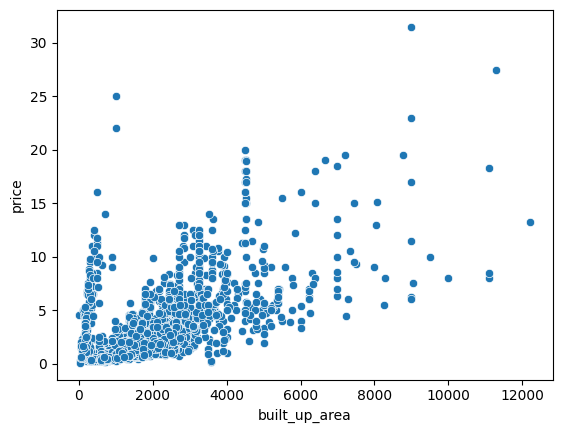

In [31]:
sns.scatterplot(x=df['built_up_area'],y=df['price'])

In [46]:
anamoly_df = df[(df['built_up_area'] < 2000) & (df['price'] > 2.5)][['price','area','built_up_area']]

In [47]:
anamoly_df.shape

(285, 3)

In [48]:
anamoly_df.sort_values('built_up_area')

,price,area,built_up_area
924,4.50,3150.0,14.0
1498,5.00,1125.0,115.0
1799,5.10,3078.0,125.0
514,2.65,1582.0,138.0
1218,4.45,1265.0,150.0
...,...,...,...
1764,3.98,2200.0,1991.0
1647,2.58,2200.0,1991.0
1565,3.40,2200.0,1991.0
2479,2.58,2200.0,1991.0


In [49]:
anamoly_df['built_up_area'] = anamoly_df['area']

In [50]:
df.update(anamoly_df)

<Axes: xlabel='built_up_area', ylabel='price'>

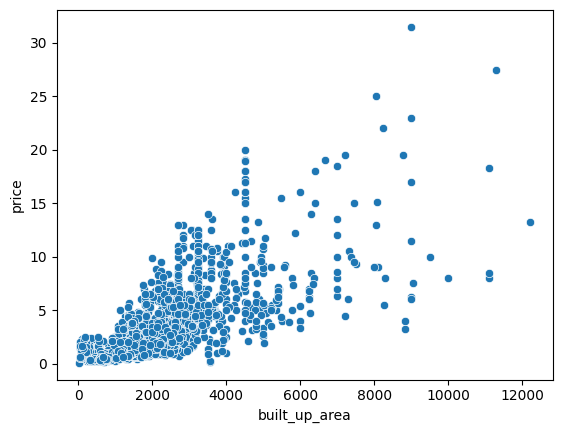

In [51]:
sns.scatterplot(x=df['built_up_area'],y=df['price'])

In [52]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
0,house,independent,sector 11,4.00,19753.0,2025.0,Built Up area: 225 (188.13 sq.m.)Carpet area: ...,5,4,1,2.0,North-East,Undefined,NaN,2025.0,180.0,0,0,0,0,0,1,0,405.000000
1,flat,indiabulls enigma,sector 110,3.30,9851.0,3350.0,Super Built up area 3350(311.23 sq.m.),4,5,3,7.0,East,Relatively New,3350.0,3032.0,NaN,0,1,0,0,0,1,101,837.500000
2,flat,puri emerald bay,sector 104,2.30,9388.0,2450.0,Super Built up area 2450(227.61 sq.m.),3,4,3+,10.0,North-East,Moderately Old,2450.0,2217.0,NaN,0,1,0,0,0,1,101,816.666667
3,house,nirvana cedar crest,sector 50,3.99,8867.0,4500.0,Plot area 4500(418.06 sq.m.),4,5,3+,4.0,North-East,New Property,NaN,4500.0,NaN,0,1,0,1,0,0,112,1125.000000
4,flat,bptp terra,sector 37,1.45,8007.0,1811.0,Super Built up area 1811(168.25 sq.m.)Built Up...,3,3,3,8.0,South-East,Relatively New,1811.0,1711.0,1611.0,0,0,0,0,0,1,149,603.666667


In [53]:
df.drop(columns=['area','areaWithType','super_built_up_area','carpet_area','area_room_ratio'],inplace=True)

In [54]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,house,independent,sector 11,4.00,19753.0,5,4,1,2.0,North-East,Undefined,2025.0,0,0,0,0,0,1,0
1,flat,indiabulls enigma,sector 110,3.30,9851.0,4,5,3,7.0,East,Relatively New,3032.0,0,1,0,0,0,1,101
2,flat,puri emerald bay,sector 104,2.30,9388.0,3,4,3+,10.0,North-East,Moderately Old,2217.0,0,1,0,0,0,1,101
3,house,nirvana cedar crest,sector 50,3.99,8867.0,4,5,3+,4.0,North-East,New Property,4500.0,0,1,0,1,0,0,112
4,flat,bptp terra,sector 37,1.45,8007.0,3,3,3,8.0,South-East,Relatively New,1711.0,0,0,0,0,0,1,149


In [55]:
df.isnull().sum()

property_type         0
society               1
sector                0
price                 0
price_per_sqft        0
bedRoom               0
bathroom              0
balcony               0
floorNum             18
facing             1038
agePossession         0
built_up_area         0
study room            0
servant room          0
store room            0
pooja room            0
others                0
furnishing_type       0
luxury_score          0
dtype: int64

### floorNum

In [57]:
df[df['floorNum'].isnull()]

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
131,house,vipul tatvam villa,sector 48,8.50,26235.0,4,4,1,NaN,NaN,Relatively New,3240.0,0,0,0,0,0,1,21
224,house,ansal sushant lok,sector 43,10.50,27911.0,4,4,2,NaN,North-East,Old Property,3762.0,0,1,0,0,0,1,59
318,house,independent,sector 5,1.50,10288.0,3,3,0,NaN,NaN,Old Property,210.0,0,0,0,0,0,1,0
425,flat,experion heartsong,sector 102,1.08,6150.0,3,3,0,NaN,NaN,Under Construction,1758.0,0,0,0,0,0,1,0
870,house,independent,sector 24,1.45,2984.0,3,3,1,NaN,NaN,Old Property,540.0,0,0,0,0,0,1,9
988,flat,NaN,sector 78,0.60,3692.0,2,2,0,NaN,NaN,Under Construction,1625.0,0,0,0,0,0,1,0
1187,house,independent,sector 7,6.50,15046.0,3,2,3+,NaN,NaN,Old Property,4320.0,0,0,0,0,0,1,9
1254,house,independent,sector 25,13.00,45710.0,6,8,3+,NaN,NaN,Relatively New,2844.0,1,1,1,1,0,2,0
1726,house,emaar mgf marbella,sector 66,9.00,21251.0,4,4,3+,NaN,South-West,Relatively New,5200.0,0,1,1,1,0,0,114
1803,house,jacob pura,sector 12,0.35,9722.0,2,1,0,NaN,NaN,Old Property,360.0,0,0,0,0,0,1,0


In [58]:
df[df['property_type'] == 'house']['floorNum'].median()

2.0

In [59]:
df['floorNum'].fillna(2.0,inplace=True)

C:\Users\kushs\AppData\Local\Temp\ipykernel_77432\15612474.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['floorNum'].fillna(2.0,inplace=True)


In [60]:
df.isnull().sum()

property_type         0
society               1
sector                0
price                 0
price_per_sqft        0
bedRoom               0
bathroom              0
balcony               0
floorNum              0
facing             1038
agePossession         0
built_up_area         0
study room            0
servant room          0
store room            0
pooja room            0
others                0
furnishing_type       0
luxury_score          0
dtype: int64

### facing

<Axes: ylabel='count'>

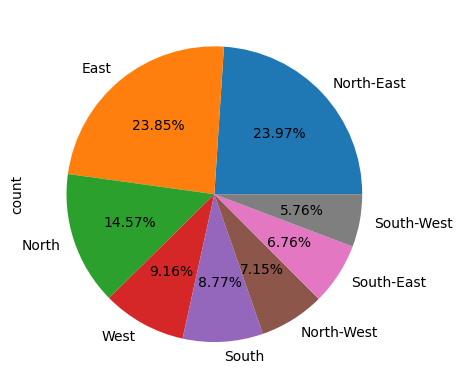

In [61]:
df['facing'].value_counts().plot(kind='pie',autopct='%0.2f%%')

In [62]:
df.drop(columns=['facing'],inplace=True)

In [63]:
df.sample(5)

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1925,flat,shapoorji pallonji joyville gurugram,sector 102,1.42,10380.0,2,2,3,14.0,Undefined,1368.0,0,0,0,0,0,1,0
3204,house,ansal sushant lok plots,sector 43,3.30,26570.0,1,1,0,2.0,Under Construction,1242.0,0,0,0,0,0,1,0
1761,flat,ashiana anmol,sohna,0.90,7059.0,2,2,2,8.0,Undefined,1275.0,0,0,0,0,0,1,0
2886,flat,eldeco accolade,sohna,0.95,6543.0,2,2,3+,6.0,New Property,1129.0,1,0,0,0,0,0,56
984,flat,central park flower valley,sector 33,1.55,11923.0,3,3,3+,7.0,New Property,1444.0,0,0,0,0,0,0,28


In [64]:
df.isnull().sum()

property_type      0
society            1
sector             0
price              0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
built_up_area      0
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

In [65]:
df[df['society'].isnull()]

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
988,flat,NaN,sector 78,0.6,3692.0,2,2,0,2.0,Under Construction,1625.0,0,0,0,0,0,1,0


In [66]:
df.drop(index=[988],inplace=True)

In [67]:
df.isnull().sum()

property_type      0
society            0
sector             0
price              0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
built_up_area      0
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

### agePossession

In [69]:
df['agePossession'].value_counts()

agePossession
Relatively New        1618
New Property           565
Moderately Old         559
Old Property           311
Undefined              305
Under Construction     266
Name: count, dtype: int64

##### undefined is missing one here

In [68]:
df[df['agePossession'] == 'Undefined']

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,house,independent,sector 11,4.00,19753.0,5,4,1,2.0,Undefined,2025.0,0,0,0,0,0,1,0
46,flat,sidhartha ncr one,sector 95,0.56,4106.0,2,2,2,10.0,Undefined,1364.0,0,0,0,0,0,1,0
58,flat,imperia elvedor,sector 37,0.55,8221.0,1,1,0,5.0,Undefined,669.0,0,0,0,0,0,1,0
67,flat,dlf icon,sector 53,5.80,20707.0,4,4,3+,18.0,Undefined,2801.0,0,0,0,0,0,1,0
79,flat,central park flower valley,sector 33,2.50,13270.0,3,3,2,1.0,Undefined,2093.0,0,0,0,0,0,1,66
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3607,house,independent,sector 7,1.20,11194.0,2,4,2,3.0,Undefined,1072.0,0,0,0,0,0,1,0
3612,flat,shree vardhman victoria,sector 70,1.75,8974.0,3,5,0,0.0,Undefined,1950.0,0,0,0,0,0,1,47
3616,flat,sidhartha ncr one,sector 95,0.55,5556.0,2,2,3,15.0,Undefined,990.0,0,0,0,0,0,1,0
3620,flat,umang winter hills,sector 77,1.40,6341.0,3,3,3,10.0,Undefined,1735.0,0,0,0,0,0,1,28


In [73]:
def mode_based_imputation(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector']) & (df['property_type'] == row['property_type'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [78]:
df['agePossession'] = df.apply(mode_based_imputation,axis=1)

In [79]:
df['agePossession'].value_counts()

agePossession
Relatively New        1731
Moderately Old         609
New Property           602
Old Property           351
Under Construction     285
Undefined               46
Name: count, dtype: int64

In [80]:
def mode_based_imputation2(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [81]:
df['agePossession'] = df.apply(mode_based_imputation2,axis=1)

In [82]:
df['agePossession'].value_counts()

agePossession
Relatively New        1739
Moderately Old         618
New Property           603
Old Property           351
Under Construction     285
Undefined               28
Name: count, dtype: int64

In [83]:
def mode_based_imputation3(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['property_type'] == row['property_type'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [84]:
df['agePossession'] = df.apply(mode_based_imputation3,axis=1)

In [85]:
df['agePossession'].value_counts()

agePossession
Relatively New        1741
Moderately Old         644
New Property           603
Old Property           351
Under Construction     285
Name: count, dtype: int64

In [86]:
df.isnull().sum()

property_type      0
society            0
sector             0
price              0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
built_up_area      0
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

In [87]:
df.to_csv('gurgaon_properties_missing_value_imputation.csv',index=False)